# Portfolio Optimization: Monte Carlo Simulation
**Author:** Michael Owen A.  
**Date:** June 2026

## Overview
This project aims to optimize asset allocation using **Monte Carlo simulations**. By simulating 500,000 potential portfolio weight combinations, we map the **Efficient Frontier** to identify the allocation that maximizes the **Sharpe Ratio**—balancing risk against expected return.

### Methodology
1. **Data Acquisition**: Fetching 5 years of historical data from Yahoo Finance for a basket of high-growth assets.
2. **Simulation**: Using random sampling to generate thousands of possible portfolio configurations.
3. **Optimization**: Applying *Modern Portfolio Theory* (MPT) principles to evaluate the risk-return profile of each portfolio.

In [1]:
# --- Import Libraries --- #
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

## Mathematical Framework

The portfolios are evaluated based on three core metrics derived from Modern Portfolio Theory:

**1. Expected Portfolio Return**
$$E(R_p) = \sum_{i=1}^{n} w_i E(R_i)$$

**2. Portfolio Volatility**
$$\sigma_p = \sqrt{w^T \Sigma w}$$
*Where:*
* $w$ is the vector of asset weights.
* $\Sigma$ is the covariance matrix of asset returns.

**3. Sharpe Ratio**
A measure of risk-adjusted return used to identify the most efficient portfolio:
$$Sharpe = \frac{E(R_p) - R_f}{\sigma_p}$$

In [2]:
# --- Configuration --- #
assets = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA', 'AVGO', 'BRK-B']
start_date = '2021-06-24'
end_date = '2026-06-24'
num_portfolios = 500000
trading_days = 252

def get_data(assets, start, end):
    df = yf.download(assets, start=start, end=end)['Close']
    try:
        tnx = yf.Ticker("^TNX")
        tnx_history = tnx.history(period='5d')
        if not tnx_history.empty:
            raw_rf = tnx_history['Close'].iloc[-1]
            rf_rate = float(raw_rf / 100)
        else:
            rf_rate = 0.04
    except Exception as e:
        print(f"Failed to retrieve ^TNX ({e}). Using default rf of 0.04")
        rf_rate = 0.04
    
    return df.dropna(axis=1, how='all'), rf_rate

def simulate_portfolios_vectorized(returns, cov_matrix, num_portfolios, rf):
    num_assets = len(returns.columns)

    weights = np.random.random((num_portfolios, num_assets))
    weights = weights / np.sum(weights, axis=1)[:, np.newaxis]

    exp_returns = returns.mean().values * trading_days
    portfolio_returns = np.dot(weights, exp_returns)

    portfolio_variance = np.sum(np.matmul(weights, cov_matrix.values) * weights, axis=1)
    portfolio_volatility = np.sqrt(portfolio_variance) * np.sqrt(trading_days)

    sharpe_ratios = (portfolio_returns - rf) / portfolio_volatility

    results = np.vstack((portfolio_returns, portfolio_volatility, sharpe_ratios))
    
    return results, weights

[*********************100%***********************]  7 of 7 completed


Risk Free Rate:  4.38%
Max Sharpe Ratio: 1.2320
Expected Return: 39.62%
Volatility: 28.60%

Optimal Asset Allocation:
AAPL: 0.35%
AMZN: 0.02%
AVGO: 33.17%
BRK-B: 30.12%
GOOG: 10.66%
MSFT: 0.70%
NVDA: 24.97%
Plot successfully saved as 'efficient_frontier.png'


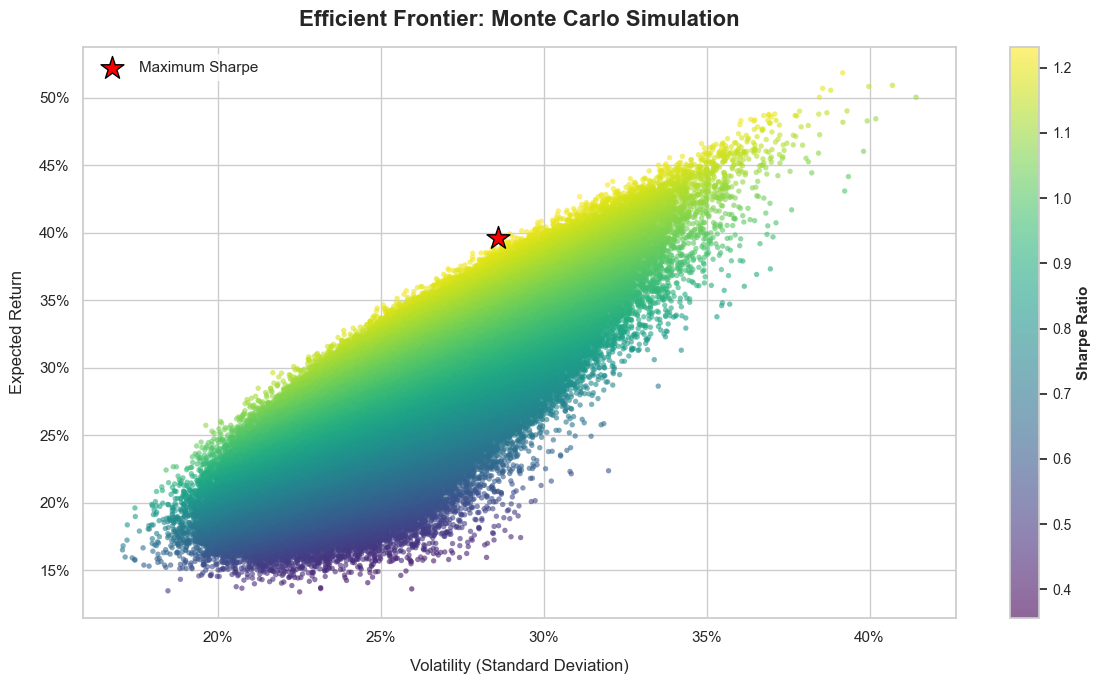

In [3]:
# --- Execution and Save --- #

# Data Preparation
data, rf_rate = get_data(assets, start_date, end_date)
returns = data.pct_change().dropna()
cov_matrix = returns.cov()

active_assets = returns.columns.tolist()

results, weights_record = simulate_portfolios_vectorized(returns, cov_matrix, num_portfolios, rf_rate)

max_sharpe_idx = np.argmax(results[2])
best_weights = weights_record[max_sharpe_idx, :]

print(f"Risk Free Rate: {rf_rate: .2%}")
print(f"Max Sharpe Ratio: {results[2, max_sharpe_idx]:.4f}")
print(f"Expected Return: {results[0, max_sharpe_idx]:.2%}")
print(f"Volatility: {results[1, max_sharpe_idx]:.2%}\n")

print("Optimal Asset Allocation:")
for asset, weight in zip(active_assets, best_weights):
    print(f"{asset}: {weight:.2%}")

sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    results[1, :], 
    results[0, :], 
    c=results[2, :], 
    cmap='viridis', 
    s=15, 
    alpha=0.6, 
    edgecolors='none'
)

cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio', fontsize=11, weight='bold')
cbar.ax.tick_params(labelsize=10)

plt.scatter(
    results[1, max_sharpe_idx], 
    results[0, max_sharpe_idx], 
    color='red', 
    marker='*', 
    s=300, 
    edgecolors='black',
    linewidths=1, 
    label='Maximum Sharpe'
)
plt.title('Efficient Frontier: Monte Carlo Simulation', fontsize=16, weight='bold', pad=15)
plt.xlabel('Volatility (Standard Deviation)', fontsize=12, labelpad=10)
plt.ylabel('Expected Return', fontsize=12, labelpad=10)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=11)
plt.tight_layout()

plt.savefig('efficient_frontier.png', dpi=300, bbox_inches='tight')
print("Plot successfully saved as 'efficient_frontier.png'")
plt.show()

### Interpretation & Asset Dominance
The vectorized Monte Carlo simulation (500,000 iterations) yields a Maximum Sharpe Ratio of **1.2320**, achieved at an Expected Annualized Return of **39.62%** and a Portfolio Volatility of **28.60%**. This represents a highly efficient risk-adjusted configuration against the current risk-free rate ($R_f$) of **4.38%** derived from the US 10-Year Treasury Yield (`^TNX`).

The optimal portfolio allocation exhibits a high concentration, heavily favoring three dominant assets that comprise over 88% of the total capital:
* **AVGO (33.17%)** and **NVDA (24.97%)**: Driven by systemic AI-infrastructure tailwinds and structural semiconductor demand over the 2021–2026 window, these tech heavyweights contribute aggressive growth. The optimizer expands exposure to these assets because their extraordinary compounding returns statistically justify their high standalone idiosyncratic volatilities.
* **BRK-B (30.12%)**: Functions as the primary stabilizing anchor. From a Mean-Variance perspective, Berkshire Hathaway provides essential downside protection and low-covariance diversification, flattening the portfolio's overall variance against the volatile tech sector.
* **GOOG (10.66%)**: Acts as a secondary layer of large-cap tech exposure, capturing residual risk-adjusted premiums that outpaced its Mega-Cap peers.
* **AAPL (0.35%), MSFT (0.70%), and AMZN (0.02%)**: Receive marginal or near-zero allocations. Mathematically, within this specific 5-year historical covariance matrix, their marginal diversification benefits were entirely subsumed by the superior risk-return profiles of AVGO, NVDA, and BRK-B.

### Project Takeaway
This simulation demonstrates the limitations of a naive, intuitive asset allocation strategy (e.g., an equally weighted 14.28% distribution). By shifting capital systematically toward the calculated Maximum Sharpe configuration, the portfolio maximizes the risk premium per unit of volatility, constructing an empirically sound baseline on the Efficient Frontier.